In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Iris.csv')

## Exploratory Data Analysis (EDA)

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
df = df.drop('Id',axis=1)

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
df.shape

(150, 5)

C:\Users\User\AppData\Local\Temp\ipykernel_18592\3556751894.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=df, palette='Set2')


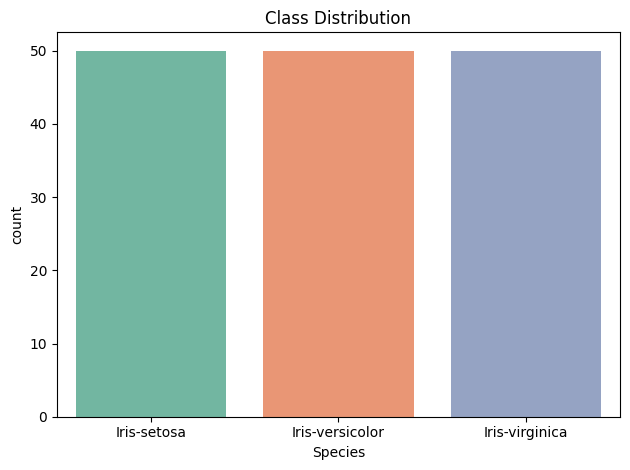

In [59]:
sns.countplot(x='Species', data=df, palette='Set2')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [12]:
X=df.drop('Species',axis=1)
y=df[['Species']]

In [13]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [14]:
y.head()

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


## Train_Test_Split

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=.25,random_state=42)

In [17]:
xtrain.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
4,5.0,3.6,1.4,0.2
32,5.2,4.1,1.5,0.1
142,5.8,2.7,5.1,1.9
85,6.0,3.4,4.5,1.6
86,6.7,3.1,4.7,1.5


In [18]:
ytrain.head()

,Species
4,Iris-setosa
32,Iris-setosa
142,Iris-virginica
85,Iris-versicolor
86,Iris-versicolor


## Label Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
le= LabelEncoder()

In [21]:
ytrain = le.fit_transform(ytrain)

d:\AiQuest\.venv\lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
ytest= le.transform(ytest)

d:\AiQuest\.venv\lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [24]:
pd.DataFrame(ytest)

,0
0,1
1,0
2,2
3,1
4,1
5,0
6,1
7,2
8,1
9,1


## Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
std = StandardScaler()

In [27]:
xtrain= std.fit_transform(xtrain)

In [29]:
xtest = std.transform(xtest)

In [31]:
xtrain

array([[-1.01827123,  1.30636523, -1.39489006, -1.35865217],
       [-0.7730102 ,  2.46390403, -1.33696359, -1.49272181],
       [-0.03722712, -0.77720463,  0.74838929,  0.92053173],
       [ 0.20803391,  0.8433497 ,  0.40083048,  0.51832281],
       [ 1.06644751,  0.14882642,  0.51668341,  0.38425317],
       [-0.52774918,  2.00088851, -1.45281653, -1.09051288],
       [-0.52774918,  1.53787299, -1.33696359, -1.35865217],
       [-0.40511866, -1.47172791, -0.06258127, -0.28609504],
       [ 0.57592545, -0.54569687,  0.74838929,  0.38425317],
       [ 0.69855596,  0.14882642,  0.98009517,  0.78646209],
       [ 0.94381699, -0.08268134,  0.34290401,  0.25018353],
       [ 1.67960008,  1.30636523,  1.32765398,  1.72494958],
       [-0.15985763, -0.3141891 ,  0.22705107,  0.11611389],
       [ 2.17012213, -0.08268134,  1.61728632,  1.18867101],
       [-0.28248815, -0.08268134,  0.40083048,  0.38425317],
       [-0.89564072,  1.07485746, -1.39489006, -1.35865217],
       [ 2.29275265, -0.

## Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf = RandomForestClassifier(random_state=12)

In [35]:
rf.fit(xtrain,ytrain)

RandomForestClassifier(random_state=12)

In [38]:
pred_ytrain = rf.predict(xtrain)

In [43]:
ytrain

array([0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1,
       2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1, 2, 0,
       0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 0, 0, 1,
       2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1,
       2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0,
       1, 2])

In [39]:
pred_ytrain

array([0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 1, 0, 2, 1, 0, 0, 0, 1,
       2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1, 2, 0,
       0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 0, 0, 1,
       2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1,
       2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 0,
       1, 2])

In [40]:
pred_ytest = rf.predict(xtest)

In [42]:
ytest

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

In [41]:
pred_ytest

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

In [54]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

In [48]:
accuracy_score(ytest,pred_ytest)

1.0

In [50]:
rf.score(xtest,ytest)

1.0

In [53]:
print(classification_report(ytest, pred_ytest))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [57]:
cm=confusion_matrix(ytest, pred_ytest)

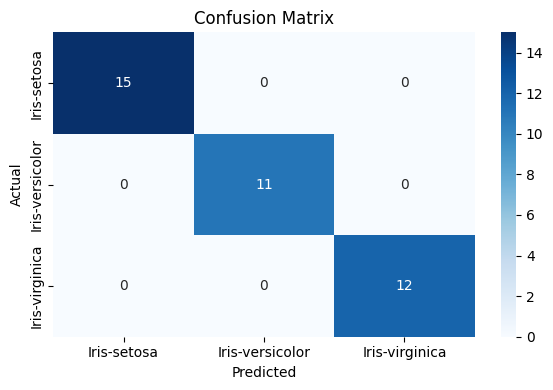

In [66]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_18592\1434560410.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


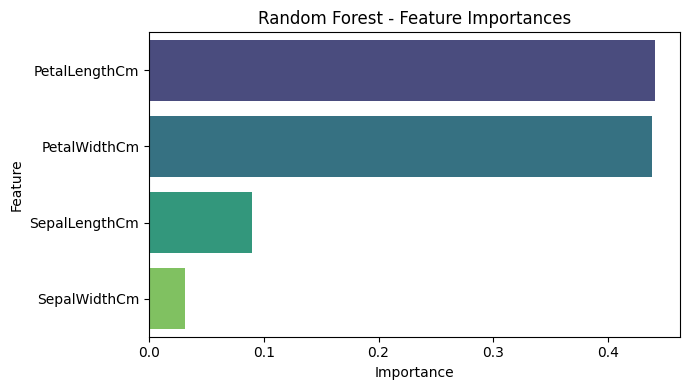

      Feature  Importance
PetalLengthCm    0.440680
 PetalWidthCm    0.438492
SepalLengthCm    0.089473
 SepalWidthCm    0.031356


In [67]:
feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
importances   = rf.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Random Forest - Feature Importances')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))